In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt
import numpy as np

I0000 00:00:1782402370.110786 2958391 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Get the images and labels
train_imgs = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/train1b_imgs.npy')
train_labels = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/train1b_labels.npy')
val_imgs = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/val1b_imgs.npy')
val_labels = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/val1b_labels.npy')
test_imgs = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/test1b_imgs.npy')
test_labels = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/test1b_labels.npy')

In [3]:
# Examine class label imbalance
neg, pos = np.bincount(train_labels.astype(int))
total = neg + pos
print('Examples:\n    Total: {}\n    Positive: {} ({:.2f}% of total)\n'.format(
    total, pos, 100 * pos / total))

Examples:
    Total: 10786
    Positive: 5393 (50.00% of total)



In [4]:
# Setup data augmentation
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
])

I0000 00:00:1782402374.728407 2958391 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38380 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:bd:00.0, compute capability: 8.0


In [5]:
# Create the dataset and group into batches
train_ds = tf.data.Dataset.from_tensor_slices((train_imgs, train_labels))
train_ds = train_ds.batch(32)

val_ds = tf.data.Dataset.from_tensor_slices((val_imgs, val_labels))
val_ds = val_ds.batch(32)

test_ds = tf.data.Dataset.from_tensor_slices((test_imgs, test_labels))
test_ds = test_ds.batch(32)

In [6]:
# Configure dataset performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [7]:
# Import pretrained model
base_model = tf.keras.applications.ResNet50(input_shape=(256, 256, 3),
                                                  include_top=False, # Don't include ImageNet classifier at the top,
                                                  weights='imagenet',
                                                 )
# Freeze base model
base_model.trainable = False

In [8]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [9]:
# Image branch
# Convert image tensor from 1 channel to 3 for the model
image_input = tf.keras.Input(shape=(256, 256, 1), name = 'image_input')
x = data_augmentation(image_input)
x = tf.keras.layers.Concatenate()([x, x, x])
x = preprocess_input(x) 

# Keep base model in inference mode
x = base_model(x, training = False)
x = layers.GlobalAveragePooling2D()(x) # (batch, H, W, C) becomes (batch, C) — a single feature vector per image
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)   # add activation="sigmoid" # maps feature vectors to probability score 0-1
model = tf.keras.Model(inputs = image_input, outputs = outputs) # wrap all layers

In [10]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 256, 256,  │          0 │ image_input[0][0] │
│ (Sequential)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256, 256,  │          0 │ sequential[0][0], │
│ (Concatenate)       │ 3)                │            │ sequential[0][0], │
│                     │                   │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 256, 256)  │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 256, 256)  │          0 │ concatenate[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 256, 256)  │          0 │ concatenate[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 256, 256,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 256,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 8, 8,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [11]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.AUC(curve="ROC"),
    ]
)

In [12]:
# Early stopping callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=3,
        restore_best_weights=True,
        mode='max'
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_auc',
        save_best_only=True,
        mode='max'
    )
]

In [13]:
initial_epochs = 20
history = model.fit(train_ds, 
                    epochs=initial_epochs, 
                    validation_data = val_ds, 
                    callbacks = callbacks)

Epoch 1/20


I0000 00:00:1782402418.904718 2958503 cuda_dnn.cc:461] Loaded cuDNN version 92302
Could not load symbol cuFuncGetName. Error: /usr/lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuFuncGetName


338/338 ━━━━━━━━━━━━━━━━━━━━ 24s 43ms/step - auc: 0.5902 - loss: 0.7062 - val_auc: 0.6724 - val_loss: 0.6420
Epoch 2/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - auc: 0.6484 - loss: 0.6649 - val_auc: 0.6903 - val_loss: 0.6388
Epoch 3/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - auc: 0.6589 - loss: 0.6586 - val_auc: 0.6960 - val_loss: 0.6359
Epoch 4/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - auc: 0.6726 - loss: 0.6482 - val_auc: 0.6962 - val_loss: 0.6331
Epoch 5/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - auc: 0.6736 - loss: 0.6469 - val_auc: 0.7000 - val_loss: 0.6282
Epoch 6/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - auc: 0.6795 - loss: 0.6438 - val_auc: 0.7115 - val_loss: 0.6302
Epoch 7/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - auc: 0.6775 - loss: 0.6459 - val_auc: 0.7046 - val_loss: 0.6257
Epoch 8/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - auc: 0.6835 - loss: 0.6414 - val_auc: 0.7126 - val_loss: 0.6274
Epoch 9/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/st

In [14]:
# See how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

Number of layers in the base model:  175


In [15]:
base_model.trainable = True

# Fine-tune from this layer onwards
fine_tune_at = len(base_model.layers) - 50

# Unfreeze only the head layers
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

In [16]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 256, 256,  │          0 │ image_input[0][0] │
│ (Sequential)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256, 256,  │          0 │ sequential[0][0], │
│ (Concatenate)       │ 3)                │            │ sequential[0][0], │
│                     │                   │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 256, 256)  │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 256, 256)  │          0 │ concatenate[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 256, 256)  │          0 │ concatenate[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 256, 256,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 256,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 8, 8,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,593,861 (90.00 MB)

 Trainable params: 16,952,577 (64.67 MB)

 Non-trainable params: 6,637,184 (25.32 MB)

 Optimizer params: 4,100 (16.02 KB)

In [17]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.AUC(curve="ROC"),
    ],
)

In [18]:
# Train the model
fine_tune_epochs = 10
total_epochs =  initial_epochs + fine_tune_epochs
history_fine = model.fit(train_ds, 
                         epochs=total_epochs,       
                         initial_epoch=initial_epochs,  
                         validation_data=val_ds,
                         callbacks=callbacks)

Epoch 21/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - auc_1: 0.6665 - loss: 0.6931

/home/anya.tongprasith001/miniconda3/envs/tfgpu/lib/python3.10/site-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: auc_1,loss,val_auc_1,val_loss
  current = self.get_monitor_value(logs)
/home/anya.tongprasith001/miniconda3/envs/tfgpu/lib/python3.10/site-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_auc available.
  if self._should_save_model(epoch, batch, logs, filepath):


338/338 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - auc_1: 0.6761 - loss: 0.6678 - val_auc_1: 0.7114 - val_loss: 0.6263
Epoch 22/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - auc_1: 0.7175 - loss: 0.6196 - val_auc_1: 0.7224 - val_loss: 0.6222
Epoch 23/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - auc_1: 0.7392 - loss: 0.6004 - val_auc_1: 0.7309 - val_loss: 0.6184
Epoch 24/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - auc_1: 0.7626 - loss: 0.5764 - val_auc_1: 0.7364 - val_loss: 0.6107
Epoch 25/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - auc_1: 0.7760 - loss: 0.5625 - val_auc_1: 0.7466 - val_loss: 0.6082
Epoch 26/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - auc_1: 0.7986 - loss: 0.5378 - val_auc_1: 0.7430 - val_loss: 0.6082
Epoch 27/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - auc_1: 0.8160 - loss: 0.5167 - val_auc_1: 0.7413 - val_loss: 0.6200
Epoch 28/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - auc_1: 0.8256 - loss: 0.5060 - val_auc_1: 0.7389 - val_loss: 0.6403
Epoch 29/30


In [19]:
# Evaluate model
model.evaluate(test_ds)

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - auc_1: 0.7596 - loss: 0.6269


[0.6269472241401672, 0.7595698833465576]

In [20]:
from sklearn.metrics import confusion_matrix

# Analyse confusion matrix
y_prob = model.predict(test_ds).reshape(-1)
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_labels.astype(int)

cm = confusion_matrix(y_true, y_pred)

57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step


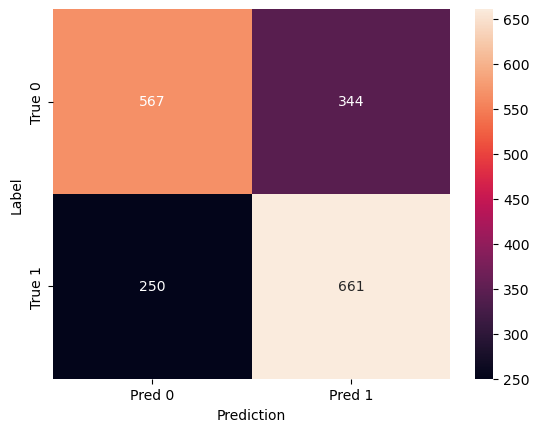

In [21]:
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'])
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

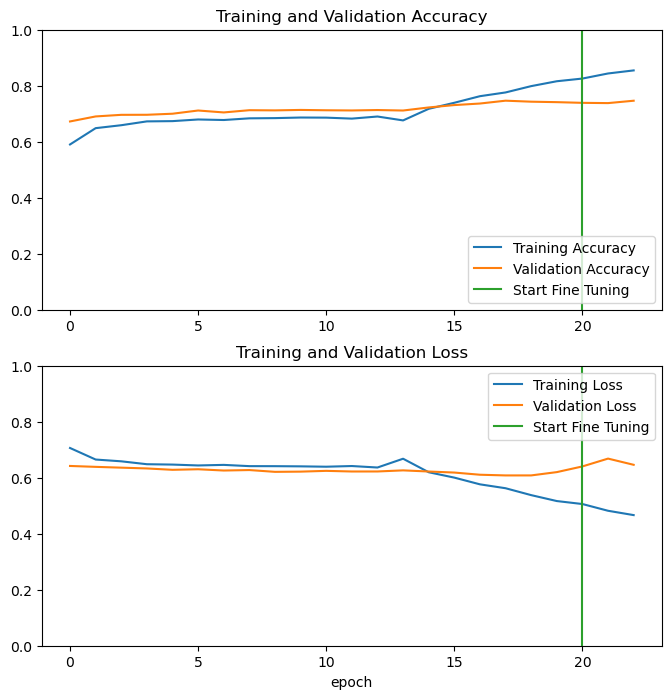

In [22]:
# Combine both for plotting
acc = history.history['auc'] + history_fine.history['auc_1']
val_acc = history.history['val_auc'] + history_fine.history['val_auc_1']
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

# Plot
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0, 1.0])
plt.plot([initial_epochs,initial_epochs],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs,initial_epochs],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [23]:
print(history.history.keys())
print(history_fine.history.keys())

dict_keys(['auc', 'loss', 'val_auc', 'val_loss'])
dict_keys(['auc_1', 'loss', 'val_auc_1', 'val_loss'])
